In [129]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

## Load train and test datasets and visualize features

In [130]:
df_train = pd.read_csv('./rmbs_train.csv')
df_test = pd.read_csv('./rmbs_test.csv')
print(f'dataframe shapes are: train {df_train.shape}, test {df_test.shape}')

dataframe shapes are: train (210900, 28), test (24600, 28)


In [131]:
df_train.describe()

,vintage_month,observation_month,original_rate,current_rate,refi_incentive,refi_incentive_pos,refi_incentive_sq,cumulative_incentive,burnout_proxy,loan_age_months,...,current_hpa,loan_balance,loan_type_arm,investment_property,underwater,high_ltv,prime_borrower,jumbo,smm,cpr
count,210900.000000,210900.000000,210900.000000,210900.000000,210900.000000,210900.000000,2.109000e+05,210900.000000,210900.000000,210900.000000,...,210900.000000,2.109000e+05,210900.000000,210900.000000,210900.000000,210900.000000,210900.000000,210900.000000,210900.000000,210900.000000
mean,55.668563,65.587482,4.641725,4.275875,0.365850,0.379893,2.441867e-01,4.023098,0.514926,10.918919,...,0.017605,4.098158e+05,0.151200,0.119635,0.007217,0.708151,0.503276,0.079815,0.002845,0.033343
std,32.999491,33.207868,0.498079,0.361464,0.332176,0.311344,3.460349e-01,4.554787,0.281759,7.088001,...,0.033260,2.152537e+05,0.358244,0.324535,0.084644,0.454614,0.499990,0.271007,0.002038,0.023355
min,0.000000,0.000000,3.471355,3.800000,-0.666901,0.000000,1.411595e-12,0.000000,0.200000,1.000000,...,-0.080000,1.000000e+05,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000031,0.000373
25%,27.000000,37.000000,4.278598,3.987234,0.136043,0.136043,2.633137e-02,0.869122,0.200000,5.000000,...,-0.001277,2.588860e+05,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.001333,0.015884
50%,58.000000,66.000000,4.527004,4.191489,0.324750,0.324750,1.082335e-01,2.486201,0.474326,10.000000,...,0.028675,3.610702e+05,0.000000,0.000000,0.000000,1.000000,1.000000,0.000000,0.002402,0.028448
75%,86.000000,94.000000,4.924645,4.487234,0.555945,0.555945,3.093179e-01,5.493512,0.770484,16.000000,...,0.042169,5.065265e+05,0.000000,0.000000,0.000000,1.000000,1.000000,0.000000,0.003873,0.045495
max,120.000000,120.000000,6.570546,5.500000,1.889733,1.889733,3.571090e+00,40.957938,1.000000,30.000000,...,0.054699,1.500000e+06,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,0.023988,0.252754


In [132]:
df_test.describe()

,vintage_month,observation_month,original_rate,current_rate,refi_incentive,refi_incentive_pos,refi_incentive_sq,cumulative_incentive,burnout_proxy,loan_age_months,...,current_hpa,loan_balance,loan_type_arm,investment_property,underwater,high_ltv,prime_borrower,jumbo,smm,cpr
count,24600.000000,24600.000000,24600.000000,24600.000000,24600.000000,24600.000000,2.460000e+04,24600.000000,24600.000000,24600.000000,...,24600.000000,2.460000e+04,24600.000000,24600.000000,24600.0,24600.000000,24600.000000,24600.000000,24600.000000,24600.000000
mean,112.280488,128.146341,4.780766,4.645760,0.135006,0.190973,1.038688e-01,3.300861,0.520800,16.865854,...,0.062879,4.018991e+05,0.149878,0.117439,0.0,0.541748,0.521748,0.074797,0.004352,0.050642
std,6.174965,5.423910,0.231881,0.174259,0.292653,0.228854,1.808768e-01,3.126286,0.281082,7.025814,...,0.012114,2.129688e+05,0.356959,0.321949,0.0,0.498264,0.499537,0.263068,0.002357,0.026495
min,95.000000,121.000000,3.944528,3.886957,-0.718329,0.000000,1.214467e-10,0.000000,0.200000,2.000000,...,0.055181,1.000000e+05,0.000000,0.000000,0.0,0.000000,0.000000,0.000000,0.000267,0.003204
25%,110.000000,123.000000,4.621987,4.628571,-0.063799,0.000000,8.463558e-03,0.891803,0.236014,12.000000,...,0.056145,2.530142e+05,0.000000,0.000000,0.0,0.000000,0.000000,0.000000,0.002729,0.032257
50%,113.000000,127.000000,4.783669,4.680000,0.115426,0.115426,3.882223e-02,2.519500,0.469611,16.500000,...,0.058072,3.550345e+05,0.000000,0.000000,0.0,1.000000,1.000000,0.000000,0.003893,0.045730
75%,116.000000,132.000000,4.948497,4.748571,0.309785,0.309785,1.195873e-01,4.812884,0.765259,22.000000,...,0.060000,4.929343e+05,0.000000,0.000000,0.0,1.000000,1.000000,0.000000,0.005459,0.063572
max,120.000000,142.000000,5.601941,4.800000,1.596596,1.596596,2.549118e+00,28.459733,1.000000,30.000000,...,0.112174,1.500000e+06,1.000000,1.000000,0.0,1.000000,1.000000,1.000000,0.022337,0.237443


### There are just 18 features. Let's start by plotting some of the features and see what relationship they have with the label
- Removed vintage and observation months since these are no informative
- refi incentive exists already. Just kept the positive version. Removed square because negative refi incentive would have opposite effect to positive refi incentive
- removed calendar month as well because the cos and sin components are included already
  
Just look at cpr for now because smm is like the monthly version of cpr. Recall cpr = 1-(1-smm)^12

18


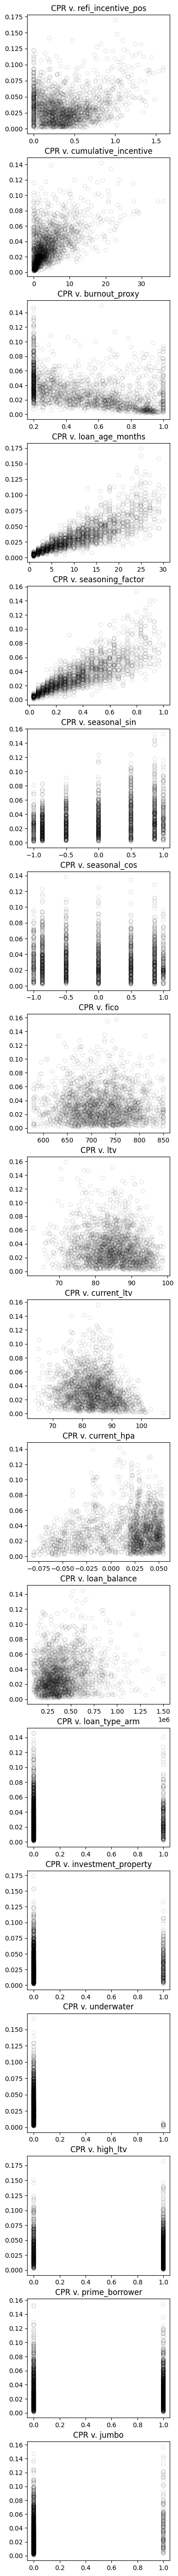

In [133]:
labels = ['smm', 'cpr']
ids = ['loan_id']
other_vars = ['vintage_month', 'observation_month', 'original_rate', 'current_rate', 'refi_incentive', 'refi_incentive_sq', 'calendar_month']
features = [col for col in df_train.columns.tolist() if col not in labels+ids+other_vars]
print(len(features))
fig, axs = plt.subplots(len(features), 1, figsize = (4, 4*len(features)))
for i, var in enumerate(features):
    ax = axs[i]
    df_plot = df_train.sample(frac = .01) 
    ax.scatter(df_plot[var], df_plot.cpr, facecolor = 'None', edgecolor = 'k', alpha = .1) 
    ax.set_title(f'CPR v. {var}')

### Immediately, some features jump out: like, loan balance, seasoning factor, ltv, loan age

## Check for correlation with dep var to get further sense of predictive power

In [136]:
 df_train[features].corrwith(df_train.cpr)

refi_incentive_pos      0.151418
cumulative_incentive    0.553755
burnout_proxy          -0.427641
loan_age_months         0.827553
seasoning_factor        0.827553
seasonal_sin            0.265866
seasonal_cos           -0.044379
fico                    0.000027
ltv                    -0.130263
current_ltv            -0.195903
current_hpa             0.179545
loan_balance            0.143282
loan_type_arm           0.006104
investment_property    -0.002363
underwater             -0.104513
high_ltv               -0.077287
prime_borrower         -0.004054
jumbo                   0.087325
dtype: float64

### Check for NaNs

In [88]:
for var in df_train.columns:
    print(df_train[var].isna().sum())

0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0


## Check for multicollinearity among features. Likely to use a linear regression type model

In [89]:
df_sample = df_train.sample(frac = .1)
df_corr = df_sample[features].corr(numeric_only=True)
r, c = np.where(df_corr > .9)
for i in range(len(r)):
    if r[i] != c[i]:
        print(features[r[i]], features[c[i]])

loan_age_months seasoning_factor
seasoning_factor loan_age_months
ltv current_ltv
current_ltv ltv


### My fault for not removing one of ltv or current_ltv. Same for seasoning factor or loan age months, which are synonymous.

In [90]:
features_final = [x for x in features if x not in ['ltv', 'loan_age_months']]

## We need to do some outlier analysis as well. Instead of assuming normal distribution and removing 3 sigma outliers, let's do flooring and capping which depends purely on distrbution of features

In [91]:
print(df_train['refi_incentive_pos'].dtype)

float64


In [149]:
def floor_and_cap(df_train, df_test, level): 
    '''level (e.g. .99, .9) is how aggressive we wish to be with the flooring and capping. 95th perc for instance is more aggressive than 99th'''
    
    df_out_train = pd.DataFrame({})
    df_out_test = pd.DataFrame({})

    #identify the categorical vars
    categorical = [col for col in df_train.columns if df_train[col].nunique() < 10]
    print(f'Identified categorical vars as {categorical}')
    
    for var in df_train.columns:

        if var not in categorical:
            
            #first, get thresholds based on training data only
            perc_max = df_train[var].quantile(level)
            perc_min = df_train[var].quantile(1.-level)
            
            #apply on train
            var_treated_train = np.where(df_train[var] > perc_max, perc_max, df_train[var])
            var_treated_train = np.where(var_treated_train < perc_min, perc_min, var_treated_train)
            df_out_train[var] = var_treated_train
            
            #apply on test
            var_treated_test = np.where(df_test[var] > perc_max, perc_max, df_test[var])
            var_treated_test = np.where(var_treated_test < perc_min, perc_min, var_treated_test)
            df_out_test[var] = var_treated_test

        else:
            df_out_train[var] = df_train[var]
            df_out_test[var] = df_test[var]
    print(df_out_train.shape)
        
    return df_out_train, df_out_test

#now, floor and cap based on training data. But also apply to test data
X_train, X_test = floor_and_cap(df_train[features_final], df_test[features_final], .99)
y_train, y_test = df_train.cpr, df_test.cpr

Identified categorical vars as ['seasonal_cos', 'loan_type_arm', 'investment_property', 'underwater', 'high_ltv', 'prime_borrower', 'jumbo']
(210900, 16)


## Next, is the dependent variable right skewed, in which case we may want to predict the log instead?

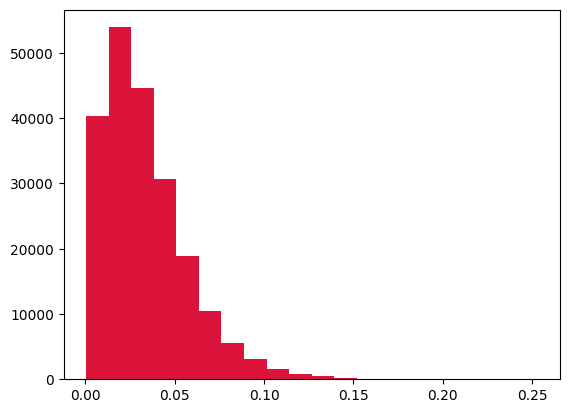

In [150]:
plt.hist(df_train.cpr, bins = 20, color='crimson');

### Looks fine

## Finally, divide the set into training, validation. Test is already there

In [151]:
df_train.columns

Index(['loan_id', 'vintage_month', 'observation_month', 'original_rate',
       'current_rate', 'refi_incentive', 'refi_incentive_pos',
       'refi_incentive_sq', 'cumulative_incentive', 'burnout_proxy',
       'loan_age_months', 'seasoning_factor', 'calendar_month', 'seasonal_sin',
       'seasonal_cos', 'fico', 'ltv', 'current_ltv', 'current_hpa',
       'loan_balance', 'loan_type_arm', 'investment_property', 'underwater',
       'high_ltv', 'prime_borrower', 'jumbo', 'smm', 'cpr'],
      dtype='object')

In [164]:
train = pd.concat([X_train, y_train], axis=1)
train['id'] = range(len(train))
train['date'] = df_train.observation_month

#split based on time
month_threshold = train.date.quantile(.7)
val = train[train.date > month_threshold]
train = train[~train.isin(val.id)]

val.drop(columns = ['id', 'date'], inplace=True)
train.drop(columns = ['id', 'date'], inplace=True)
X_train, X_val = train[features_final], val[features_final]
y_train, y_val = train.cpr, val.cpr

print(X_train.shape, X_val.shape, X_test.shape)
print(y_train.shape, y_val.shape, y_test.shape)

(210900, 16) (63000, 16) (24600, 16)
(210900,) (63000,) (24600,)


In [165]:
#save
X_train.to_csv('X_train.csv', index=False)
y_train.to_csv('y_train.csv', index=False)
X_test.to_csv('X_test.csv', index=False)
y_test.to_csv('y_test.csv', index=False)